# Employee Attrition Prediction Using Machine Learning

### BCA Minor Project

**Project Domain:** Human Resources Analytics  
**Problem Type:** Binary Classification  
**Final Deployment:** Streamlit Web Application

---

## Project Overview

Employee attrition is an important challenge for organizations because employee turnover can increase recruitment costs, training requirements, workload, and operational disruption.

This project develops a machine learning-based system to predict whether an employee is likely to leave an organization.

The project follows a complete machine learning workflow, starting from data understanding and preprocessing and ending with model deployment through a Streamlit web application.

# 1. Project Objectives

The main objectives of this project are:

1. To understand employee-related data and identify factors associated with attrition.
2. To clean and preprocess the dataset for machine learning.
3. To analyze the distribution of the target variable.
4. To identify and examine potential outliers.
5. To address the class imbalance present in the target variable.
6. To identify the most important features for predicting employee attrition.
7. To train multiple machine learning classification models.
8. To compare Logistic Regression, Decision Tree, and Random Forest.
9. To evaluate the models using multiple performance metrics.
10. To select and save the best-performing model.
11. To load the saved model and perform prediction on new employee data.
12. To deploy the prediction system using Streamlit.

# 2. Import Required Libraries

The following libraries are used for data manipulation, visualization, preprocessing, machine learning, and model evaluation.

In [175]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from scipy.stats import chi2_contingency

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    cross_val_score
)

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    precision_recall_curve
)

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


# 3. Load Dataset

The Employee Attrition dataset is loaded using Pandas.

The dataset contains employee-related demographic, job, compensation, satisfaction, and experience attributes. The target variable is `Attrition`.

In [176]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

print("Dataset Shape:", df.shape)

display(df.head())

Dataset Shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


# 4. Understanding the Dataset

Before applying machine learning algorithms, the structure and characteristics of the dataset are examined.

In [177]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

print("\nDataset Description")
display(df.describe())

Number of Rows: 1470
Number of Columns: 35

Column Names:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


# 5. Data Quality Check

Missing values and duplicate records are checked before beginning the modelling process.

In [178]:
print("Total Missing Values:", df.isnull().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())

df = df.drop_duplicates()

print("Dataset Shape After Removing Duplicates:", df.shape)

Total Missing Values: 0
Duplicate Rows: 0
Dataset Shape After Removing Duplicates: (1470, 35)


# 6. Target Variable Analysis

The target variable is `Attrition`.

- `No` represents an employee who stayed.
- `Yes` represents an employee who left.

The distribution of the target variable is analyzed to identify possible class imbalance.

In [179]:
print(df["Attrition"].value_counts())

print("\nPercentage Distribution:")
print(
    (df["Attrition"].value_counts(normalize=True) * 100)
    .round(2)
)

Attrition
No     1233
Yes     237
Name: count, dtype: int64

Percentage Distribution:
Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64


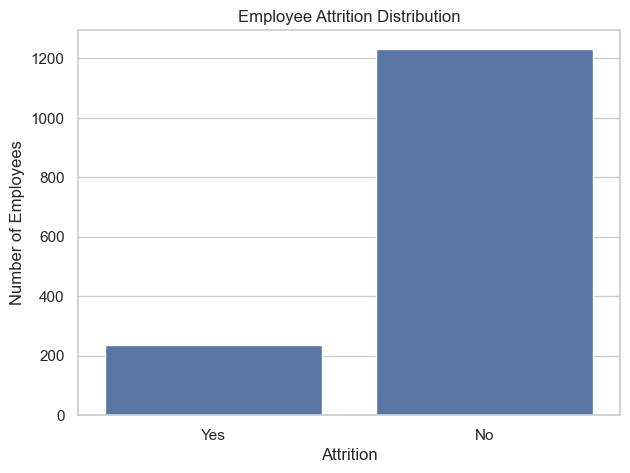

In [180]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Attrition")

plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")

plt.show()

# 7. Class Imbalance Handling

The target variable is imbalanced because the number of employees who stayed is considerably higher than the number of employees who left.

For this reason, accuracy alone is not sufficient for evaluating the classification models.

To address this issue:

- `class_weight="balanced"` is used during model training.
- Precision, Recall, F1-score, and ROC-AUC are used along with Accuracy.
- A stratified train-test split is used to maintain the class distribution.

In [181]:
class_distribution = df["Attrition"].value_counts()

print("Stayed (No):", class_distribution["No"])
print("Left (Yes):", class_distribution["Yes"])

Stayed (No): 1233
Left (Yes): 237


# 8. Outlier Analysis

Outliers can affect some machine learning algorithms and therefore need to be investigated.

The following numerical variables are examined using box plots:

- Age
- MonthlyIncome
- TotalWorkingYears
- YearsAtCompany
- YearsWithCurrManager

Outliers are not automatically removed because extreme values may represent valid employee characteristics, such as employees with high income or long work experience.

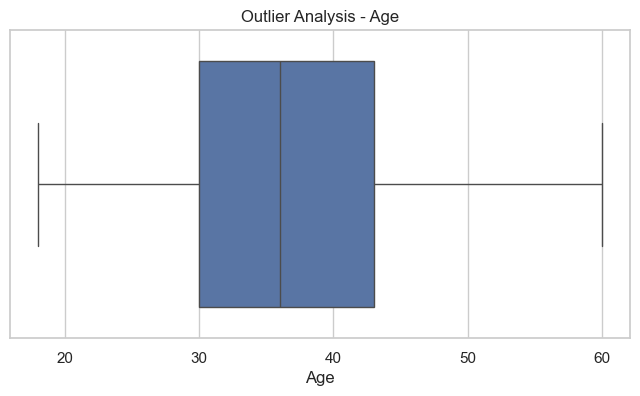

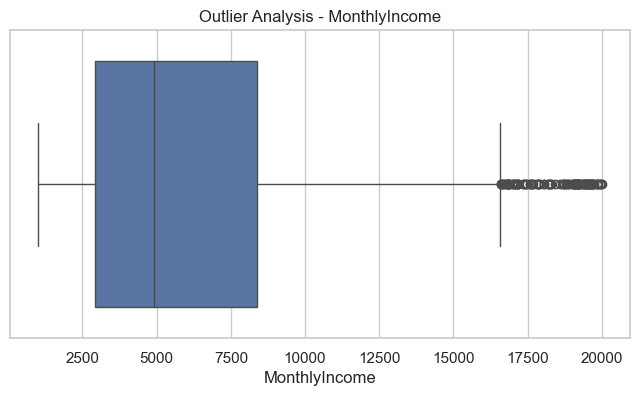

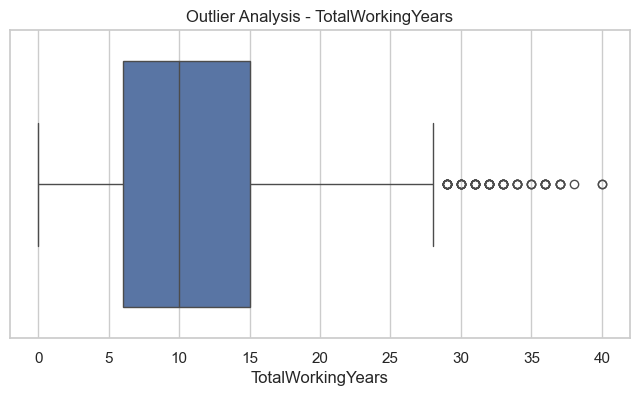

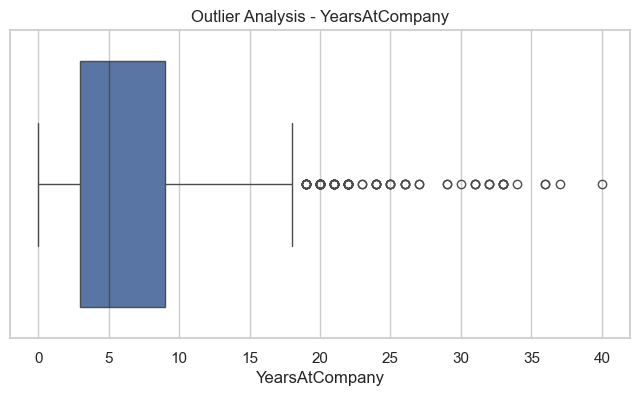

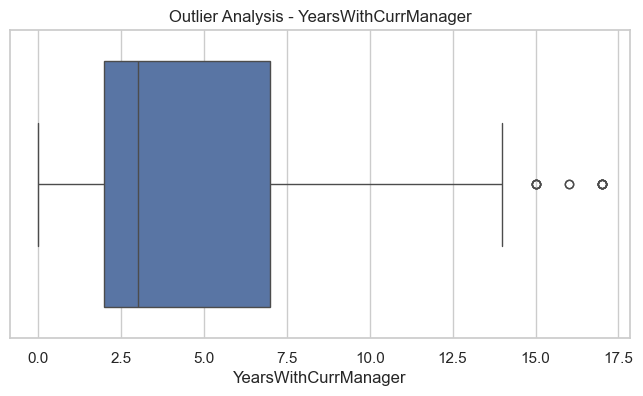

In [182]:
outlier_columns = [
    "Age",
    "MonthlyIncome",
    "TotalWorkingYears",
    "YearsAtCompany",
    "YearsWithCurrManager"
]

for col in outlier_columns:

    plt.figure(figsize=(8, 4))

    sns.boxplot(x=df[col])

    plt.title(f"Outlier Analysis - {col}")
    plt.xlabel(col)

    plt.show()

## IQR-Based Outlier Detection

The Interquartile Range (IQR) method is used to identify potential extreme observations.

In [183]:
outlier_summary = []

for col in outlier_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = (
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ).sum()

    outlier_summary.append({
        "Feature": col,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": outlier_count
    })

outlier_summary = pd.DataFrame(outlier_summary)

display(outlier_summary)

,Feature,Lower Bound,Upper Bound,Outlier Count
0,Age,10.5,62.5,0
1,MonthlyIncome,-5291.0,16581.0,114
2,TotalWorkingYears,-7.5,28.5,63
3,YearsAtCompany,-6.0,18.0,104
4,YearsWithCurrManager,-5.5,14.5,14


### Outlier Treatment Decision

The identified observations are retained because the extreme values can represent legitimate employee characteristics.

Therefore, no arbitrary outlier deletion is performed.

# 9. Exploratory Data Analysis

Exploratory Data Analysis is performed to understand the relationship between employee characteristics and attrition.

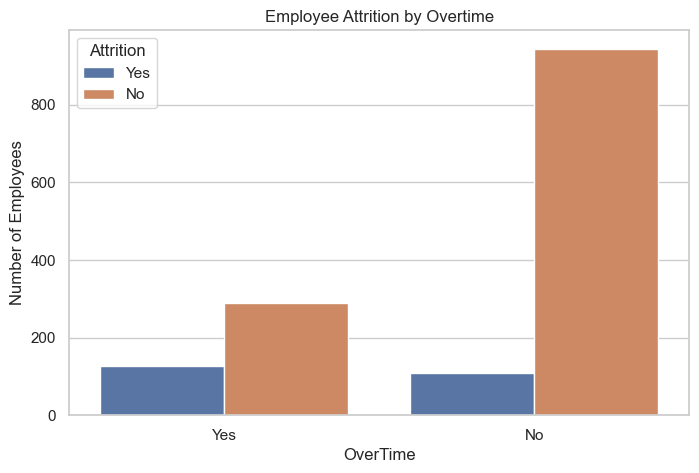

In [184]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="OverTime",
    hue="Attrition"
)

plt.title("Employee Attrition by Overtime")
plt.xlabel("OverTime")
plt.ylabel("Number of Employees")

plt.show()

In [185]:
overtime_attrition = pd.crosstab(
    df["OverTime"],
    df["Attrition"],
    normalize="index"
) * 100

display(overtime_attrition.round(2))

Attrition,No,Yes
OverTime,,
No,89.56,10.44
Yes,69.47,30.53


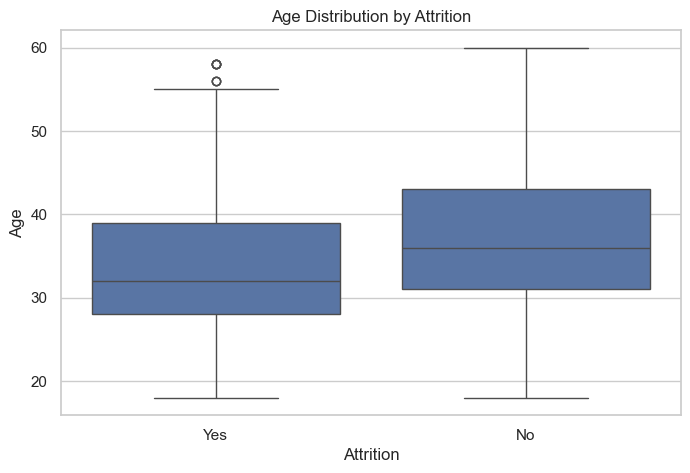

In [186]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Attrition",
    y="Age"
)

plt.title("Age Distribution by Attrition")
plt.xlabel("Attrition")
plt.ylabel("Age")

plt.show()

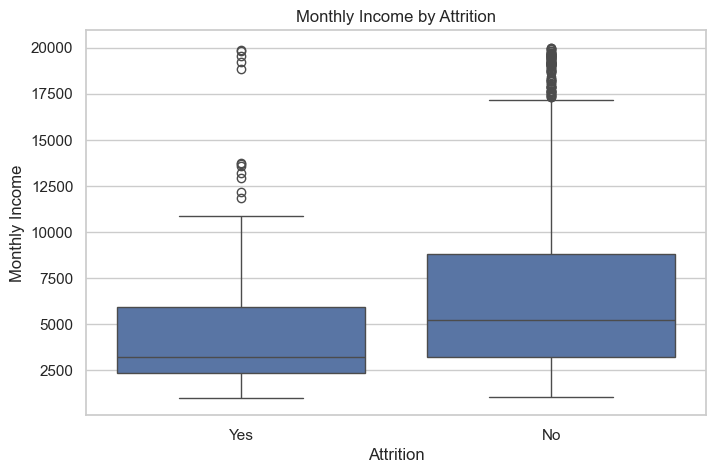

In [187]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Attrition",
    y="MonthlyIncome"
)

plt.title("Monthly Income by Attrition")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")

plt.show()

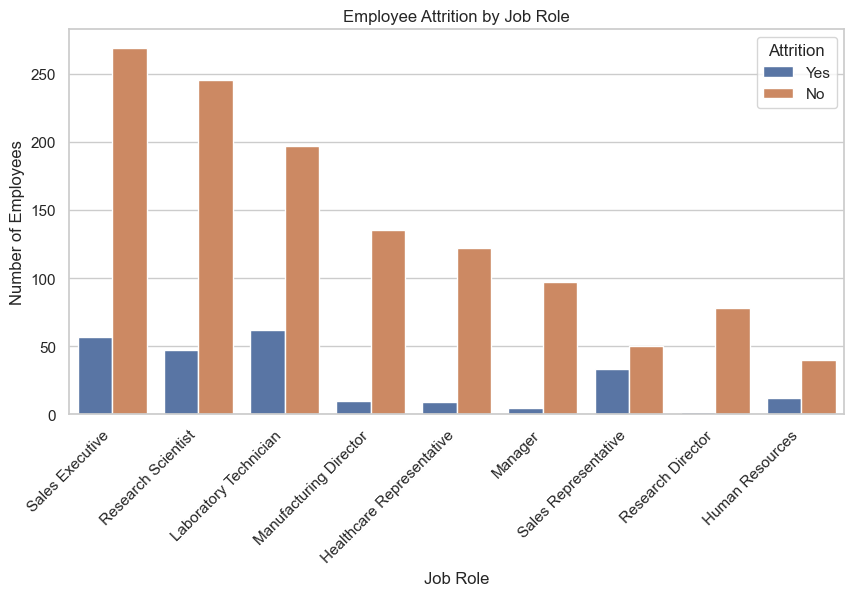

In [188]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="JobRole",
    hue="Attrition"
)

plt.title("Employee Attrition by Job Role")
plt.xlabel("Job Role")
plt.ylabel("Number of Employees")

plt.xticks(rotation=45, ha="right")

plt.show()

# 10. EDA Findings

The exploratory analysis provides useful insights into employee attrition patterns.

Key areas examined include:

- Overtime status
- Employee age
- Monthly income
- Job role
- Work experience

These variables show differences between employees who stayed and employees who left and therefore provide useful candidates for machine learning.

# 10.1 Additional Exploratory Data Analysis

Additional analysis is performed to examine employee satisfaction, job level, work-life balance, and relationships among important numerical variables.

These analyses help in understanding employee characteristics associated with attrition before model training.

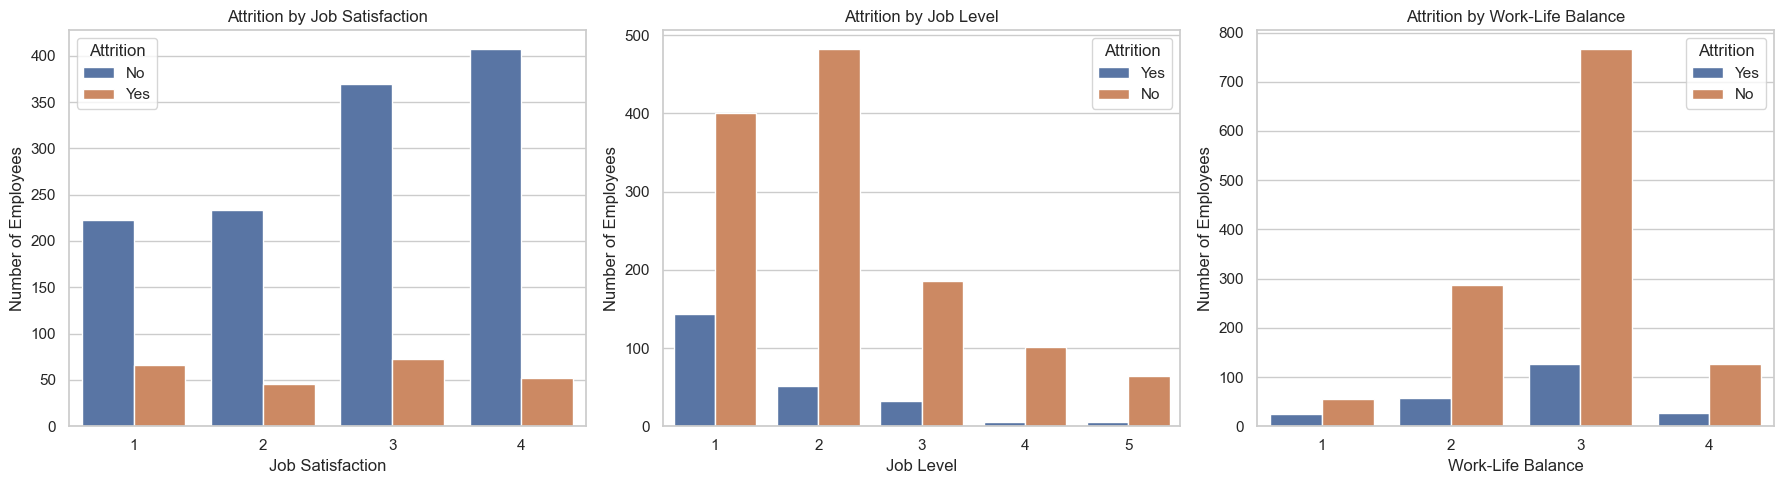

In [189]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(
    data=df,
    x="JobSatisfaction",
    hue="Attrition",
    ax=axes[0]
)
axes[0].set_title("Attrition by Job Satisfaction")
axes[0].set_xlabel("Job Satisfaction")
axes[0].set_ylabel("Number of Employees")

sns.countplot(
    data=df,
    x="JobLevel",
    hue="Attrition",
    ax=axes[1]
)
axes[1].set_title("Attrition by Job Level")
axes[1].set_xlabel("Job Level")
axes[1].set_ylabel("Number of Employees")

sns.countplot(
    data=df,
    x="WorkLifeBalance",
    hue="Attrition",
    ax=axes[2]
)
axes[2].set_title("Attrition by Work-Life Balance")
axes[2].set_xlabel("Work-Life Balance")
axes[2].set_ylabel("Number of Employees")

plt.tight_layout()
plt.show()

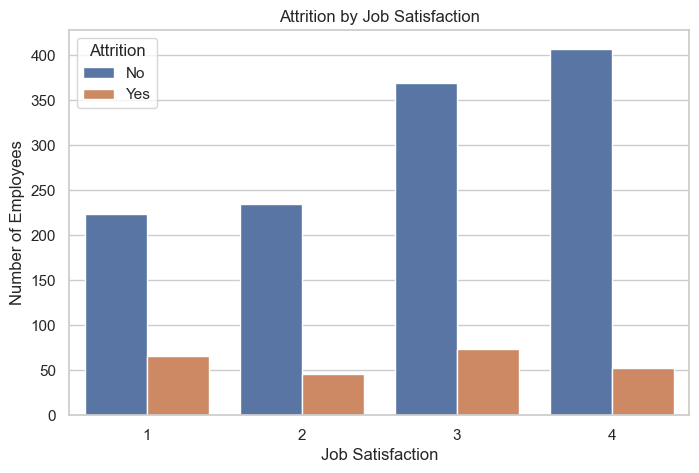

In [190]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="JobSatisfaction",
    hue="Attrition"
)

plt.title("Attrition by Job Satisfaction")
plt.xlabel("Job Satisfaction")
plt.ylabel("Number of Employees")

plt.show()

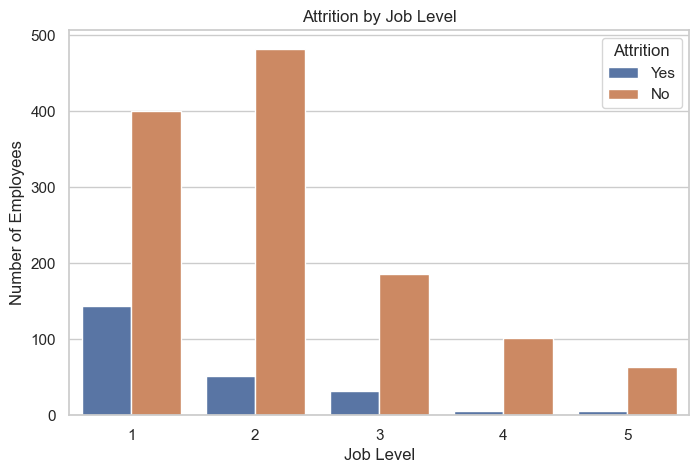

In [191]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="JobLevel",
    hue="Attrition"
)

plt.title("Attrition by Job Level")
plt.xlabel("Job Level")
plt.ylabel("Number of Employees")

plt.show()

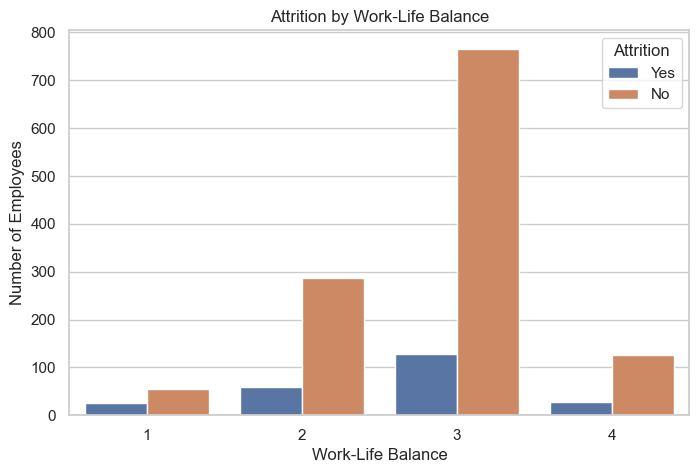

In [192]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="WorkLifeBalance",
    hue="Attrition"
)

plt.title("Attrition by Work-Life Balance")
plt.xlabel("Work-Life Balance")
plt.ylabel("Number of Employees")

plt.show()

### Additional EDA Findings

The additional analysis helps identify differences in attrition across job satisfaction, job level, and work-life balance categories.

These variables provide useful context for understanding employee attrition patterns and support the subsequent statistical and machine learning analysis.

# 10.2 Correlation Analysis

Correlation analysis is performed to examine the relationships among important numerical variables.

The correlation matrix helps identify variables that show stronger relationships with other employee-related attributes.

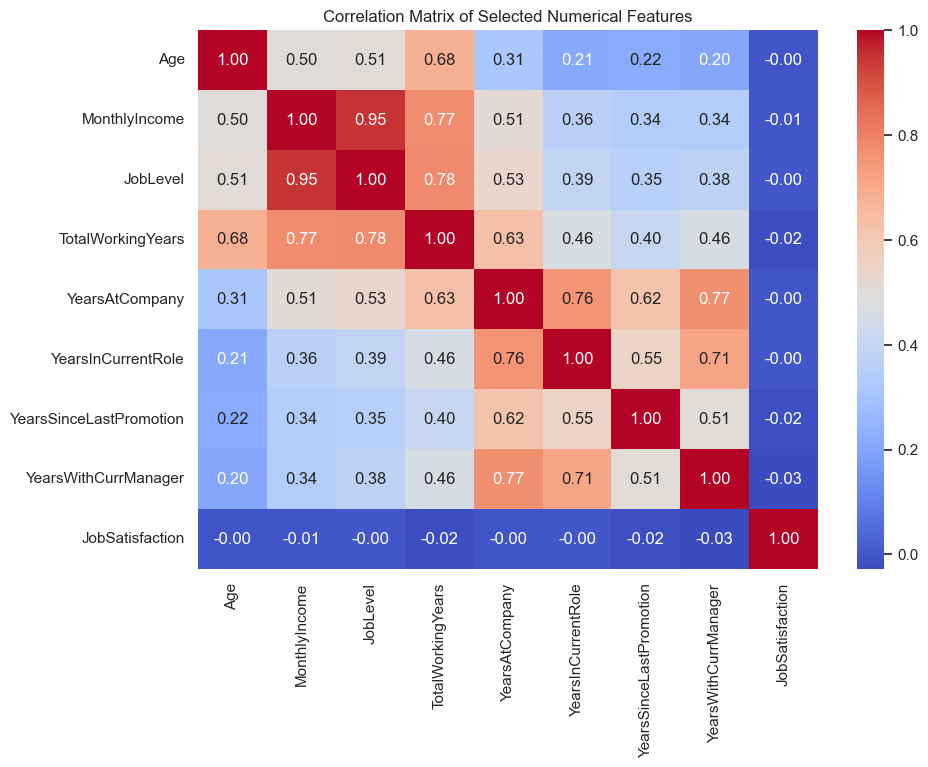

In [193]:
correlation_features = [
    "Age",
    "MonthlyIncome",
    "JobLevel",
    "TotalWorkingYears",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsSinceLastPromotion",
    "YearsWithCurrManager",
    "JobSatisfaction"
]

correlation_matrix = df[correlation_features].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Selected Numerical Features")

plt.show()

# 10.3 Statistical Analysis — Chi-Square Test

The Chi-Square test of independence is used to examine whether categorical variables have a statistically significant association with employee attrition.

A p-value below 0.05 is considered statistically significant.

In [194]:
categorical_features = [
    "OverTime",
    "JobSatisfaction",
    "JobLevel",
    "WorkLifeBalance",
    "MaritalStatus",
    "JobRole"
]

chi_square_results = []

for feature in categorical_features:

    contingency_table = pd.crosstab(
        df[feature],
        df["Attrition"]
    )

    chi2, p_value, dof, expected = chi2_contingency(
        contingency_table
    )

    chi_square_results.append({
        "Feature": feature,
        "Chi-Square": chi2,
        "p-value": p_value,
        "Significant": "Yes" if p_value < 0.05 else "No"
    })

chi_square_results = pd.DataFrame(
    chi_square_results
)

display(
    chi_square_results.sort_values(
        by="p-value"
    ).round(4)
)

,Feature,Chi-Square,p-value,Significant
0,OverTime,87.5643,0.0000,Yes
5,JobRole,86.1903,0.0000,Yes
2,JobLevel,72.5290,0.0000,Yes
4,MaritalStatus,46.1637,0.0000,Yes
1,JobSatisfaction,17.5051,0.0006,Yes
3,WorkLifeBalance,16.3251,0.0010,Yes


### Chi-Square Test Interpretation

The Chi-Square results indicate which categorical variables have a statistically significant association with employee attrition.

Variables with a p-value below 0.05 are considered statistically significant at the 5% significance level.

# 11. Data Preprocessing

The target variable is converted into numerical form:

- No → 0
- Yes → 1

Identifier and constant columns that do not provide useful predictive information are removed.

Categorical variables are converted into numerical form using one-hot encoding.

In [195]:
df["Attrition"] = df["Attrition"].map({"No": 0,"Yes": 1})

In [196]:
drop_columns = [
    "Attrition",
    "EmployeeCount",
    "EmployeeNumber",
    "Over18",
    "StandardHours"
]

X = df.drop(columns=drop_columns)
y = df["Attrition"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (1470, 30)
Target Shape: (1470,)


In [197]:
X = pd.get_dummies(X,drop_first=True)

print("Features After Encoding:", X.shape[1])

Features After Encoding: 44


# 12. Train-Test Split

The dataset is divided into training and testing sets using an 80:20 ratio.

Stratification is applied to preserve the proportion of both target classes in the training and testing datasets.

In [198]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.20,random_state=42,stratify=y)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (1176, 44)
Testing Data: (294, 44)


# 13. Feature Selection

Using all available features can make the model more difficult to interpret and deploy.

Therefore, feature importance is calculated using a Random Forest trained only on the training dataset.

Using only the training dataset for feature selection prevents information from the test dataset from influencing the feature selection process.

The six most important features are selected for the final modelling stage.

In [199]:
feature_selector = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42
)

feature_selector.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [200]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": feature_selector.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

display(feature_importance.head(15))

,Feature,Importance
0,MonthlyIncome,0.095751
1,OverTime_Yes,0.074631
2,YearsAtCompany,0.074061
3,TotalWorkingYears,0.070827
4,Age,0.067017
5,YearsWithCurrManager,0.059293
6,StockOptionLevel,0.046871
7,DailyRate,0.040934
8,JobLevel,0.039446
9,NumCompaniesWorked,0.035547


In [201]:
top_6_features = feature_importance.head(6)["Feature"].tolist()

print("Top 6 Selected Features:")

for i, feature in enumerate(top_6_features, start=1):
    print(f"{i}. {feature}")

Top 6 Selected Features:
1. MonthlyIncome
2. OverTime_Yes
3. YearsAtCompany
4. TotalWorkingYears
5. Age
6. YearsWithCurrManager


In [202]:
X_train_top6 = X_train[top_6_features].copy()
X_test_top6 = X_test[top_6_features].copy()

print("Top-6 Training Data:", X_train_top6.shape)
print("Top-6 Testing Data:", X_test_top6.shape)

Top-6 Training Data: (1176, 6)
Top-6 Testing Data: (294, 6)


# 14. Top-6 Feature Importance

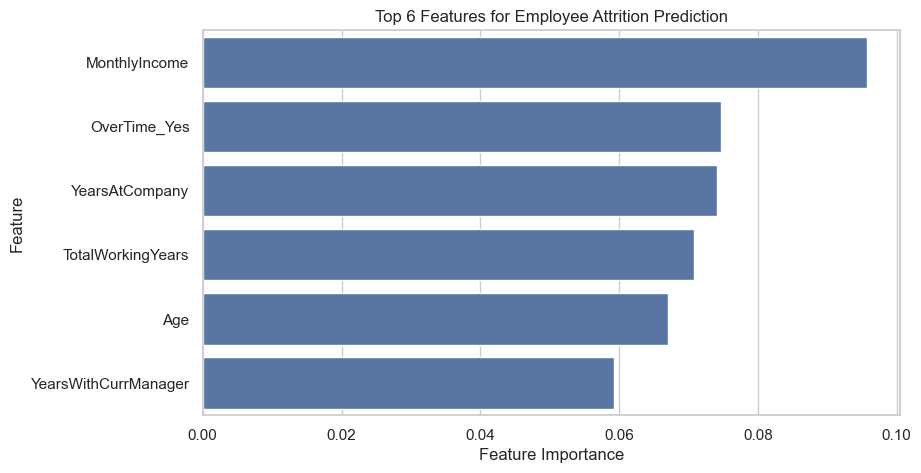

In [203]:
top6_importance = feature_importance.head(6)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=top6_importance,
    x="Importance",
    y="Feature"
)

plt.title("Top 6 Features for Employee Attrition Prediction")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.show()

# 15. Machine Learning Model 1 — Logistic Regression

Logistic Regression is used as a baseline classification algorithm.

StandardScaler is applied because Logistic Regression benefits from features being on a comparable scale.

Balanced class weights are used to reduce the effect of target class imbalance.

In [204]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_top6)
X_test_scaled = scaler.transform(X_test_top6)

In [205]:
logistic_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

y_pred_logistic = logistic_model.predict(X_test_scaled)

y_prob_logistic = logistic_model.predict_proba(
    X_test_scaled
)[:, 1]

In [206]:
logistic_accuracy = accuracy_score(
    y_test,
    y_pred_logistic
)

logistic_precision = precision_score(
    y_test,
    y_pred_logistic
)

logistic_recall = recall_score(
    y_test,
    y_pred_logistic
)

logistic_f1 = f1_score(
    y_test,
    y_pred_logistic
)

logistic_auc = roc_auc_score(
    y_test,
    y_prob_logistic
)

print("Logistic Regression")
print("-------------------")
print("Accuracy :", round(logistic_accuracy, 4))
print("Precision:", round(logistic_precision, 4))
print("Recall   :", round(logistic_recall, 4))
print("F1 Score :", round(logistic_f1, 4))
print("ROC-AUC  :", round(logistic_auc, 4))

Logistic Regression
-------------------
Accuracy : 0.6905
Precision: 0.3
Recall   : 0.7021
F1 Score : 0.4204
ROC-AUC  : 0.7461


# 16. Machine Learning Model 2 — Decision Tree

Decision Tree is a non-linear classification algorithm that creates decision rules based on the input features.

The tree depth is restricted to reduce unnecessary complexity and overfitting.

In [207]:
decision_tree = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42
)

decision_tree.fit(
    X_train_top6,
    y_train
)

y_pred_tree = decision_tree.predict(
    X_test_top6
)

y_prob_tree = decision_tree.predict_proba(
    X_test_top6
)[:, 1]

In [208]:
tree_accuracy = accuracy_score(
    y_test,
    y_pred_tree
)

tree_precision = precision_score(
    y_test,
    y_pred_tree
)

tree_recall = recall_score(
    y_test,
    y_pred_tree
)

tree_f1 = f1_score(
    y_test,
    y_pred_tree
)

tree_auc = roc_auc_score(
    y_test,
    y_prob_tree
)

print("Decision Tree")
print("-------------")
print("Accuracy :", round(tree_accuracy, 4))
print("Precision:", round(tree_precision, 4))
print("Recall   :", round(tree_recall, 4))
print("F1 Score :", round(tree_f1, 4))
print("ROC-AUC  :", round(tree_auc, 4))

Decision Tree
-------------
Accuracy : 0.6837
Precision: 0.2604
Recall   : 0.5319
F1 Score : 0.3497
ROC-AUC  : 0.6476


# 17. Machine Learning Model 3 — Random Forest

Random Forest is an ensemble learning algorithm that combines multiple decision trees.

It is used as the primary candidate for the final model because it can capture non-linear relationships and provides feature importance information.

Balanced class weights are used to account for the imbalanced target variable.

In [209]:
random_forest = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42
)

random_forest.fit(
    X_train_top6,
    y_train
)

y_pred_rf = random_forest.predict(
    X_test_top6
)

y_prob_rf = random_forest.predict_proba(
    X_test_top6
)[:, 1]

In [210]:
rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

rf_precision = precision_score(
    y_test,
    y_pred_rf
)

rf_recall = recall_score(
    y_test,
    y_pred_rf
)

rf_f1 = f1_score(
    y_test,
    y_pred_rf
)

rf_auc = roc_auc_score(
    y_test,
    y_prob_rf
)

print("Random Forest")
print("-------------")
print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1 Score :", round(rf_f1, 4))
print("ROC-AUC  :", round(rf_auc, 4))

Random Forest
-------------
Accuracy : 0.7619
Precision: 0.338
Recall   : 0.5106
F1 Score : 0.4068
ROC-AUC  : 0.7343


# 17.1 Hyperparameter Tuning — Random Forest

Hyperparameter tuning is performed to identify a better configuration of the Random Forest model.

GridSearchCV is used with 5-fold cross-validation. F1-score is used as the optimization metric because the target variable is imbalanced.

In [211]:
rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7, None],
    "min_samples_leaf": [1, 2, 4]
}

rf_grid_search = GridSearchCV(
    estimator=RandomForestClassifier(
        class_weight="balanced",
        random_state=42
    ),
    param_grid=rf_param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

rf_grid_search.fit(
    X_train_top6,
    y_train
)

best_rf = rf_grid_search.best_estimator_

print("Best Parameters:")
print(rf_grid_search.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(round(rf_grid_search.best_score_, 4))

Best Parameters:
{'max_depth': 5, 'min_samples_leaf': 4, 'n_estimators': 200}

Best Cross-Validation F1 Score:
0.463


### Tuned Random Forest Evaluation

The tuned Random Forest model is evaluated on the unseen test dataset using Accuracy, Precision, Recall, F1-score, and ROC-AUC.

In [212]:
y_pred_tuned = best_rf.predict(
    X_test_top6
)

y_prob_tuned = best_rf.predict_proba(
    X_test_top6
)[:, 1]

tuned_accuracy = accuracy_score(
    y_test,
    y_pred_tuned
)

tuned_precision = precision_score(
    y_test,
    y_pred_tuned
)

tuned_recall = recall_score(
    y_test,
    y_pred_tuned
)

tuned_f1 = f1_score(
    y_test,
    y_pred_tuned
)

tuned_auc = roc_auc_score(
    y_test,
    y_prob_tuned
)

print("Tuned Random Forest")
print("-------------------")
print("Accuracy :", round(tuned_accuracy, 4))
print("Precision:", round(tuned_precision, 4))
print("Recall   :", round(tuned_recall, 4))
print("F1 Score :", round(tuned_f1, 4))
print("ROC-AUC  :", round(tuned_auc, 4))

Tuned Random Forest
-------------------
Accuracy : 0.7619
Precision: 0.338
Recall   : 0.5106
F1 Score : 0.4068
ROC-AUC  : 0.7339


# 17.2 Five-Fold Stratified Cross-Validation

Stratified 5-fold cross-validation is used to evaluate the consistency of the tuned Random Forest model across different subsets of the training data.

Stratification ensures that the proportion of attrition classes is approximately maintained in each fold.

In [213]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    best_rf,
    X_train_top6,
    y_train,
    cv=skf,
    scoring="f1"
)

print("Cross-Validation F1 Scores:")
print(np.round(cv_scores, 4))

print("\nMean Cross-Validation F1 Score:",
      round(cv_scores.mean(), 4))

print("Standard Deviation:",
      round(cv_scores.std(), 4))

Cross-Validation F1 Scores:
[0.3846 0.411  0.4598 0.4737 0.4286]

Mean Cross-Validation F1 Score: 0.4315
Standard Deviation: 0.0323


# 18. Model Performance Comparison

The three trained models are evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

Since the target variable is imbalanced, F1-score and ROC-AUC are considered along with accuracy when selecting the final model.

In [214]:
comparison = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Tuned Random Forest"
    ],

    "Accuracy": [
        logistic_accuracy,
        tree_accuracy,
        rf_accuracy,
        tuned_accuracy
    ],

    "Precision": [
        logistic_precision,
        tree_precision,
        rf_precision,
        tuned_precision
    ],

    "Recall": [
        logistic_recall,
        tree_recall,
        rf_recall,
        tuned_recall
    ],

    "F1 Score": [
        logistic_f1,
        tree_f1,
        rf_f1,
        tuned_f1
    ],

    "ROC-AUC": [
        logistic_auc,
        tree_auc,
        rf_auc,
        tuned_auc
    ]
})

display(comparison.round(4))

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.6905,0.3000,0.7021,0.4204,0.7461
1,Decision Tree,0.6837,0.2604,0.5319,0.3497,0.6476
2,Random Forest,0.7619,0.3380,0.5106,0.4068,0.7343
3,Tuned Random Forest,0.7619,0.3380,0.5106,0.4068,0.7339


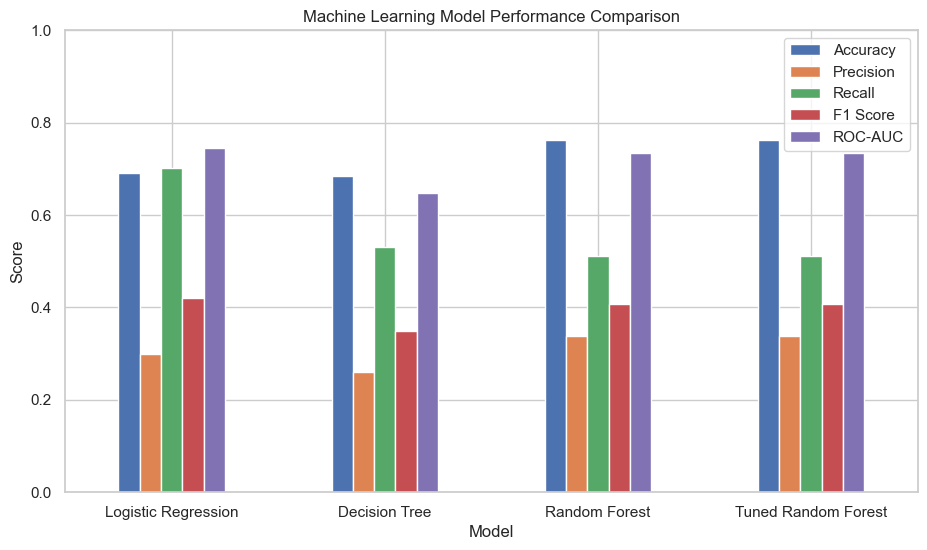

In [215]:
comparison_plot = comparison.set_index("Model")

comparison_plot.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Machine Learning Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(rotation=0)

plt.show()

# 19. Classification Reports

Classification reports provide class-wise precision, recall, F1-score, and support.

These metrics are especially useful for evaluating the minority class representing employees who left.

In [216]:
print("LOGISTIC REGRESSION")
print(
    classification_report(
        y_test,
        y_pred_logistic,
        target_names=["Stayed", "Left"]
    )
)

print("\nDECISION TREE")
print(
    classification_report(
        y_test,
        y_pred_tree,
        target_names=["Stayed", "Left"]
    )
)

print("\nRANDOM FOREST")
print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=["Stayed", "Left"]
    )
)

LOGISTIC REGRESSION
              precision    recall  f1-score   support

      Stayed       0.92      0.69      0.79       247
        Left       0.30      0.70      0.42        47

    accuracy                           0.69       294
   macro avg       0.61      0.70      0.60       294
weighted avg       0.82      0.69      0.73       294


DECISION TREE
              precision    recall  f1-score   support

      Stayed       0.89      0.71      0.79       247
        Left       0.26      0.53      0.35        47

    accuracy                           0.68       294
   macro avg       0.57      0.62      0.57       294
weighted avg       0.79      0.68      0.72       294


RANDOM FOREST
              precision    recall  f1-score   support

      Stayed       0.90      0.81      0.85       247
        Left       0.34      0.51      0.41        47

    accuracy                           0.76       294
   macro avg       0.62      0.66      0.63       294
weighted avg       0.81 

# 20. Confusion Matrix — Random Forest

The confusion matrix shows:

- True Negatives: Employees correctly predicted to stay.
- True Positives: Employees correctly predicted to leave.
- False Positives: Employees predicted to leave but who stayed.
- False Negatives: Employees predicted to stay but who left.

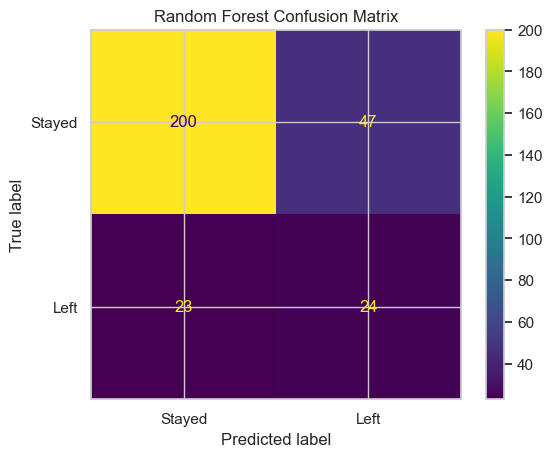

In [217]:
cm = confusion_matrix(
    y_test,
    y_pred_rf
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Stayed", "Left"]
)

disp.plot()

plt.title("Random Forest Confusion Matrix")

plt.show()

# 21. ROC Curve and AUC

The ROC curve is used to evaluate how effectively each model distinguishes between employees who stay and employees who leave.

The Area Under the Curve (AUC) provides a single measure of discrimination performance.

In [218]:
fpr_logistic, tpr_logistic, _ = roc_curve(
    y_test,
    y_prob_logistic
)

fpr_tree, tpr_tree, _ = roc_curve(
    y_test,
    y_prob_tree
)

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    y_prob_rf
)

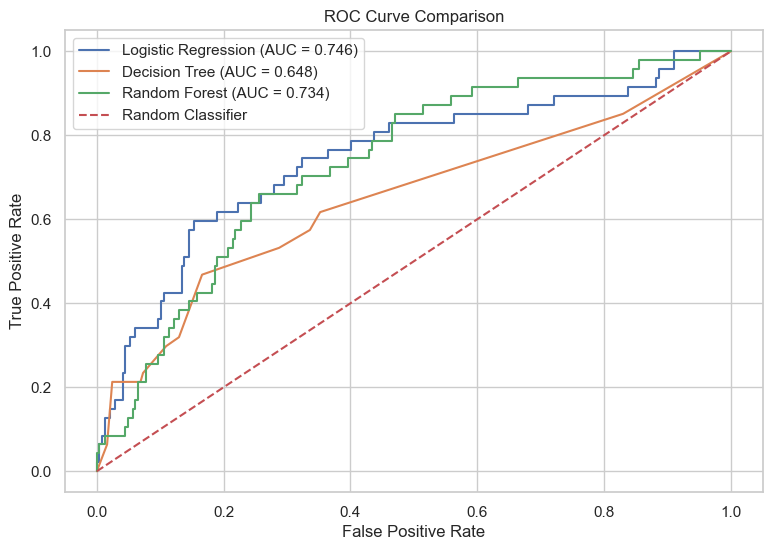

In [219]:
plt.figure(figsize=(9, 6))

plt.plot(
    fpr_logistic,
    tpr_logistic,
    label=f"Logistic Regression (AUC = {logistic_auc:.3f})"
)

plt.plot(
    fpr_tree,
    tpr_tree,
    label=f"Decision Tree (AUC = {tree_auc:.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {rf_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

# 21.1 Precision-Recall Curve

The Precision-Recall curve provides additional evaluation of the classifier, particularly when the target classes are imbalanced.

It shows the trade-off between Precision and Recall at different classification thresholds.

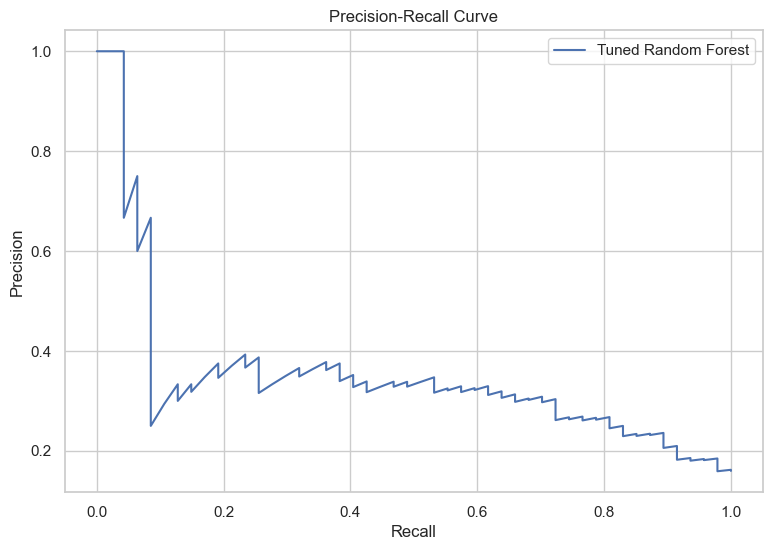

In [220]:
precision_tuned, recall_tuned, _ = precision_recall_curve(
    y_test,
    y_prob_tuned
)

plt.figure(figsize=(9, 6))

plt.plot(
    recall_tuned,
    precision_tuned,
    label="Tuned Random Forest"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.legend()

plt.show()

# 22. Final Model Selection

The final model is selected based on the overall evaluation of the trained and tuned models.

Accuracy, Precision, Recall, F1-score, ROC-AUC, and cross-validation performance are considered during model selection.

The tuned Random Forest is selected as the final deployment model because it provides a strong overall balance of classification performance and is suitable for the selected six-feature input structure.

In [221]:
final_model = best_rf

print("Final Model: Tuned Random Forest")

print("\nBest Parameters:")
print(rf_grid_search.best_params_)

Final Model: Tuned Random Forest

Best Parameters:
{'max_depth': 5, 'min_samples_leaf': 4, 'n_estimators': 200}


# 22.1 Final Model Evaluation

The selected tuned Random Forest model is evaluated on the test dataset using multiple classification metrics.

These metrics provide a more complete assessment than accuracy alone, especially because the target variable is imbalanced.

In [222]:
final_predictions = final_model.predict(
    X_test_top6
)

final_probabilities = final_model.predict_proba(
    X_test_top6
)[:, 1]

final_accuracy = accuracy_score(
    y_test,
    final_predictions
)

final_precision = precision_score(
    y_test,
    final_predictions
)

final_recall = recall_score(
    y_test,
    final_predictions
)

final_f1 = f1_score(
    y_test,
    final_predictions
)

final_auc = roc_auc_score(
    y_test,
    final_probabilities
)

print("Final Tuned Random Forest")
print("-------------------------")
print("Accuracy :", round(final_accuracy, 4))
print("Precision:", round(final_precision, 4))
print("Recall   :", round(final_recall, 4))
print("F1 Score :", round(final_f1, 4))
print("ROC-AUC  :", round(final_auc, 4))

Final Tuned Random Forest
-------------------------
Accuracy : 0.7619
Precision: 0.338
Recall   : 0.5106
F1 Score : 0.4068
ROC-AUC  : 0.7339


# 23. Final Model Feature Importance

The feature importance values of the final Random Forest model are visualized to understand which selected attributes contribute most to the model's predictions.

In [223]:
final_importance = pd.DataFrame({
    "Feature": X_train_top6.columns,
    "Importance": final_model.feature_importances_
})

final_importance = final_importance.sort_values(
    by="Importance",
    ascending=False
)

display(
    final_importance.round(4)
)

,Feature,Importance
0,MonthlyIncome,0.2205
3,TotalWorkingYears,0.1827
4,Age,0.1729
1,OverTime_Yes,0.1686
2,YearsAtCompany,0.1430
5,YearsWithCurrManager,0.1124


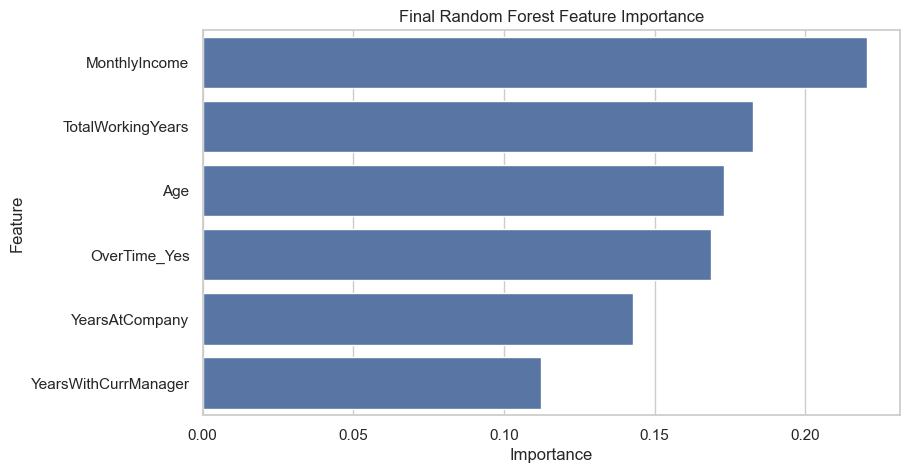

In [224]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=final_importance,
    x="Importance",
    y="Feature"
)

plt.title("Final Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

# 23.1 Explainable AI — SHAP Analysis

SHAP (SHapley Additive exPlanations) is used to understand how individual features contribute to the predictions of the final Random Forest model.

The SHAP summary plot provides a global view of feature influence across the test dataset.

In [225]:
import shap

print(shap.__version__)

0.52.0


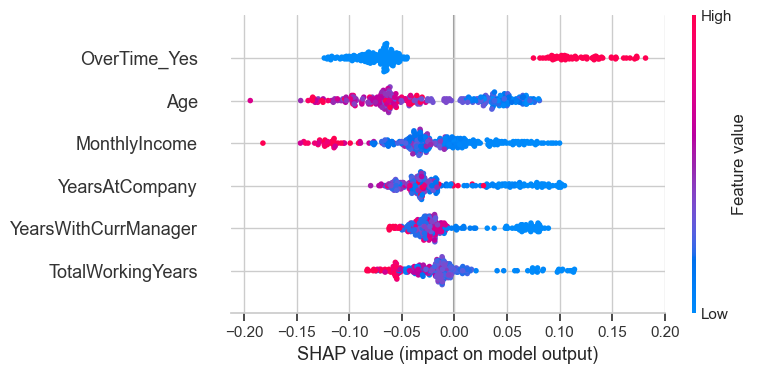

In [226]:
import shap

explainer = shap.TreeExplainer(
    final_model
)

shap_values = explainer.shap_values(
    X_test_top6
)

if isinstance(shap_values, list):

    shap.summary_plot(
        shap_values[1],
        X_test_top6
    )

elif len(shap_values.shape) == 3:

    shap.summary_plot(
        shap_values[:, :, 1],
        X_test_top6
    )

else:

    shap.summary_plot(
        shap_values,
        X_test_top6
    )

# 24. Save the Final Model

The final tuned Random Forest model is saved using Python's pickle module.

The selected feature list is also saved so that the deployment application can create input data in exactly the same order used during training.

In [227]:
with open(
    "employee_attrition_model.pkl",
    "wb"
) as file:

    pickle.dump(
        final_model,
        file
    )


with open(
    "model_features.pkl",
    "wb"
) as file:

    pickle.dump(
        list(X_train_top6.columns),
        file
    )

print("Final tuned model saved successfully.")
print("Model feature list saved successfully.")

Final tuned model saved successfully.
Model feature list saved successfully.


# 25. Load the Saved Model

The saved model is loaded again to verify that the trained model can be reused without retraining.

In [228]:
with open(
    "employee_attrition_model.pkl",
    "rb"
) as file:

    loaded_model = pickle.load(file)


with open(
    "model_features.pkl",
    "rb"
) as file:

    loaded_features = pickle.load(file)


print("Model loaded successfully.")
print("Required Features:")
print(loaded_features)

Model loaded successfully.
Required Features:
['MonthlyIncome', 'OverTime_Yes', 'YearsAtCompany', 'TotalWorkingYears', 'Age', 'YearsWithCurrManager']


In [229]:
loaded_predictions = loaded_model.predict(
    X_test_top6
)

loaded_probabilities = loaded_model.predict_proba(
    X_test_top6
)[:, 1]

loaded_accuracy = accuracy_score(
    y_test,
    loaded_predictions
)

loaded_f1 = f1_score(
    y_test,
    loaded_predictions
)

loaded_auc = roc_auc_score(
    y_test,
    loaded_probabilities
)

print("Loaded Model Verification")
print("-------------------------")
print("Accuracy :", round(loaded_accuracy, 4))
print("F1 Score :", round(loaded_f1, 4))
print("ROC-AUC  :", round(loaded_auc, 4))

Loaded Model Verification
-------------------------
Accuracy : 0.7619
F1 Score : 0.4068
ROC-AUC  : 0.7339


# 26. Prediction for a New Employee

The saved model can be used to predict the attrition status of a new employee.

The input data must contain the same six selected features and must follow the same feature order used during training.

In [230]:
new_employee = pd.DataFrame([{
    "MonthlyIncome": 5000,
    "OverTime_Yes": 1,
    "YearsAtCompany": 5,
    "TotalWorkingYears": 8,
    "Age": 30,
    "YearsWithCurrManager": 3
}])

new_employee = new_employee[
    loaded_features
]

display(new_employee)

,MonthlyIncome,OverTime_Yes,YearsAtCompany,TotalWorkingYears,Age,YearsWithCurrManager
0,5000,1,5,8,30,3


In [231]:
prediction = loaded_model.predict(
    new_employee
)[0]

probability = loaded_model.predict_proba(
    new_employee
)[0][1]

print("Prediction Result")
print("-----------------")

if prediction == 1:

    print("Employee is likely to leave.")

else:

    print("Employee is likely to stay.")

print(
    "Attrition Probability:",
    round(probability * 100, 2),
    "%"
)

Prediction Result
-----------------
Employee is likely to leave.
Attrition Probability: 53.92 %


# 27. Conclusion

This project developed an end-to-end machine learning system for predicting employee attrition.

The dataset was first examined and cleaned before performing exploratory data analysis. The target variable was found to be imbalanced, so balanced class weights and multiple evaluation metrics were used.

Potential outliers were investigated using box plots and the IQR method. Extreme observations were retained when they represented plausible employee characteristics.

Feature selection was performed using a Random Forest trained only on the training dataset. The six most important features were then used to train three classification models: Logistic Regression, Decision Tree, and Random Forest.

The models were evaluated using accuracy, precision, recall, F1-score, confusion matrix, and ROC-AUC. Based on the overall evaluation, Random Forest was selected as the final deployment model.

The final model was saved, loaded again, tested on new employee data, and prepared for deployment using Streamlit.

# 28. Limitations

1. The dataset may not represent the workforce characteristics of every organization.
2. Employee attrition depends on many organizational and personal factors that may not be available in the dataset.
3. Model predictions are estimates and may not always represent actual employee behaviour.
4. Model performance may change when applied to data from a different organization.
5. The selected six-feature model prioritizes interpretability and deployment simplicity.

# 29. Future Scope

The project can be further enhanced through:

1. Testing additional machine learning algorithms such as Gradient Boosting and XGBoost.
2. Probability threshold optimization according to specific HR requirements.
3. Integration with a real-time HR database.
4. Continuous monitoring of model performance after deployment.
5. Adding authentication and role-based access to the deployed application.
6. Providing personalized risk explanations for HR users.
7. Periodic retraining of the model using updated employee data.
8. Monitoring model fairness and potential bias across different employee groups.

In [232]:
import os

files = [
    "employee_attrition_model.pkl",
    "model_features.pkl"
]

for file in files:
    if os.path.exists(file):
        print(f"✅ {file} found — {os.path.getsize(file)} bytes")
    else:
        print(f"❌ {file} not found")

✅ employee_attrition_model.pkl found — 820533 bytes
✅ model_features.pkl found — 113 bytes
